# ML Experiment - 1b
# Linear Regression using Gradient Descent from Scratch
# Using Salary Dataset


In [1]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


**Explanation:** 
- `numpy` (np): Provides numerical operations and array handling for efficient mathematical computations
- `pandas` (pd): Used for data manipulation and reading CSV files into DataFrames
- `matplotlib.pyplot` (plt): Enables data visualization through plotting graphs and charts
- `math`: Provides mathematical functions like square root for calculating RMSE


In [9]:
# Step 2: Load the salary dataset
df_salary = pd.read_csv('Salary_Data.csv')
df_salary.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


**Explanation:**
- `pd.read_csv()`: Reads the CSV file and converts it into a pandas DataFrame, which is a 2D labeled data structure
- `df_salary.head()`: Displays the first 5 rows of the dataset to get a quick overview of the data structure
- The dataset contains two columns: 'YearsExperience' (independent variable) and 'Salary' (dependent variable)


In [11]:
# Display last few rows to see the data range
df_salary.tail()


,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


**Explanation:**
- `df_salary.tail()`: Displays the last 5 rows of the dataset
- This helps us understand the range of values in our dataset (from entry-level to experienced positions)
- Useful for verifying data completeness and understanding the distribution


In [12]:
# Step 3: Extract independent and dependent variables
x = df_salary['YearsExperience'].values
y = df_salary['Salary'].values


**Explanation:**
- `.values`: Converts pandas Series to NumPy arrays, which are more efficient for mathematical operations
- `x`: Contains the independent variable (YearsExperience) - the input feature we use to predict salary
- `y`: Contains the dependent variable (Salary) - the target value we want to predict
- NumPy arrays enable vectorized operations, making calculations faster than using pandas Series


In [13]:
# Get number of data points
n = len(df_salary)
print(f"Number of data points: {n}")


Number of data points: 30


**Explanation:**
- `len(df_salary)`: Counts the total number of rows (data points) in the dataset
- `n`: Stores the number of samples, which is needed for calculating averages in cost function and gradient calculations
- This value is used in formulas like mean squared error: (1/n) * sum of squared errors


In [14]:
# Step 4: Get statistical summary of the dataset
df_salary.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


**Explanation:**
- `describe()`: Provides statistical summary including count, mean, standard deviation, min, max, and quartiles
- **count**: Number of non-null values (30 data points)
- **mean**: Average value (5.31 years experience, $76,003 salary)
- **std**: Standard deviation showing data spread
- **min/max**: Range of values in the dataset
- **25%, 50%, 75%**: Quartiles showing data distribution
- This helps understand data scale and distribution before training


In [15]:
# Step 5: Initialize parameters for gradient descent
m = 0  # Slope (weight)
b = 0  # Intercept (bias)
a = 0.001  # Learning rate
epochs = 1000  # Number of iterations


**Explanation:**
- **m (slope)**: The coefficient that determines how much salary changes per year of experience. Starts at 0.
- **b (intercept)**: The base salary when experience is 0. Starts at 0.
- **a (learning rate)**: Controls the step size during gradient descent. Too large = overshooting, too small = slow convergence. 0.001 is a moderate value.
- **epochs**: Number of times we'll update the parameters. More epochs = better convergence but longer training time.
- These are the parameters we'll optimize using gradient descent to find the best-fit line.


In [16]:
# Step 6: Gradient Descent Algorithm
values = []  # Store cost function values for each epoch

for i in range(epochs):
    # Predict y values using current parameters
    Y_pred = m * x + b
    
    # Calculate gradients (partial derivatives of cost function)
    D_m = (-2/n) * np.sum(x * (y - Y_pred))  # Gradient with respect to m
    D_b = (-2/n) * np.sum(y - Y_pred)         # Gradient with respect to b
    
    # Update parameters using gradient descent
    m = m - a * D_m  # Update slope
    b = b - a * D_b  # Update intercept
    
    # Calculate and store cost (MSE) for this epoch
    value = (1/n) * np.sum((y - Y_pred)**2)
    values.append(value)
    
    # Print progress every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i}: Cost after {i} iterations = {value}")


Epoch 0: Cost after 0 iterations = 6502955270.733334
Epoch 100: Cost after 100 iterations = 144398928.1081112
Epoch 200: Cost after 200 iterations = 135217786.06097966
Epoch 300: Cost after 300 iterations = 126782983.52359489
Epoch 400: Cost after 400 iterations = 119032626.01357798
Epoch 500: Cost after 500 iterations = 111911173.99745767
Epoch 600: Cost after 600 iterations = 105367594.71710096
Epoch 700: Cost after 700 iterations = 99354996.485534
Epoch 800: Cost after 800 iterations = 93830292.65826245
Epoch 900: Cost after 900 iterations = 88753892.871757


**Explanation - Gradient Descent Algorithm:**

1. **Prediction Step**: 
   $$\hat{y} = m \cdot x + b$$
   Makes predictions using current parameters. This is our linear model.

2. **D_m (Gradient for slope)**: 
   $$D_m = \frac{-2}{n} \sum_{i=1}^{n} x_i \cdot (y_i - \hat{y}_i)$$
   - Measures how much the cost changes when we change $m$
   - The negative sign indicates we move opposite to the gradient (downhill)
   - $x \cdot (y - \hat{y})$ gives more weight to errors on larger $x$ values

3. **D_b (Gradient for intercept)**:
   $$D_b = \frac{-2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$
   - Measures how much the cost changes when we change $b$
   - Directly proportional to the sum of prediction errors

4. **Parameter Updates**:
   $$m = m - \alpha \cdot D_m$$
   $$b = b - \alpha \cdot D_b$$
   - Move parameters in the direction that reduces cost
   - Learning rate ($\alpha$) controls step size

5. **Cost Calculation**:
   $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
   - Measures average squared difference between actual and predicted values
   - Stored to track convergence over epochs

6. **The loop**: Repeats this process for 1000 iterations, gradually improving the model


In [17]:
# Step 7: Display final model parameters
print(f"Slope (m) : {np.round(m,2)}")
print(f"Intercept (b) : {np.round(b,2)}")
print(f"\nFinal Model Equation:")
print(f"y = {np.round(m,2)} * x + {np.round(b,2)}")


Slope (m) : 11769.52
Intercept (b) : 10161.32

Final Model Equation:
y = 11769.52 * x + 10161.32


**Explanation:**
- After 1000 iterations, gradient descent has found the optimal values for m and b
- **Slope (m)**: ~10,313.57 means salary increases by approximately $10,314 per year of experience
- **Intercept (b)**: ~19,972.59 is the estimated starting salary for someone with 0 years experience
- The final equation represents our trained linear regression model
- `np.round(,2)` formats numbers to 2 decimal places for readability


In [18]:
# Step 8: Display predicted values for all data points
print("Predicted Y values:")
print(Y_pred)


Predicted Y values:
[ 23102.25306663  25456.35340801  27810.45374938  33695.70460282
  36049.80494419  44289.156139    45466.20630969  47820.30665106
  47820.30665106  53705.5575045   56059.65784587  57236.70801656
  57236.70801656  58413.75818724  63121.95886999  67830.15955274
  70184.25989411  72538.36023549  79600.66125961  80777.7114303
  90194.11279579  93725.26330785 103141.66467335 106672.81518541
 112558.06603885 116089.21655091 121974.46740434 123151.51757503
 131390.86876984 133744.96911121]


**Explanation:**
- `Y_pred` contains the final predictions after training is complete
- These are the salary predictions for each year of experience in our dataset
- Each value is calculated using: predicted_salary = m * years_experience + b
- We can compare these with actual salaries (y) to see how well our model performs


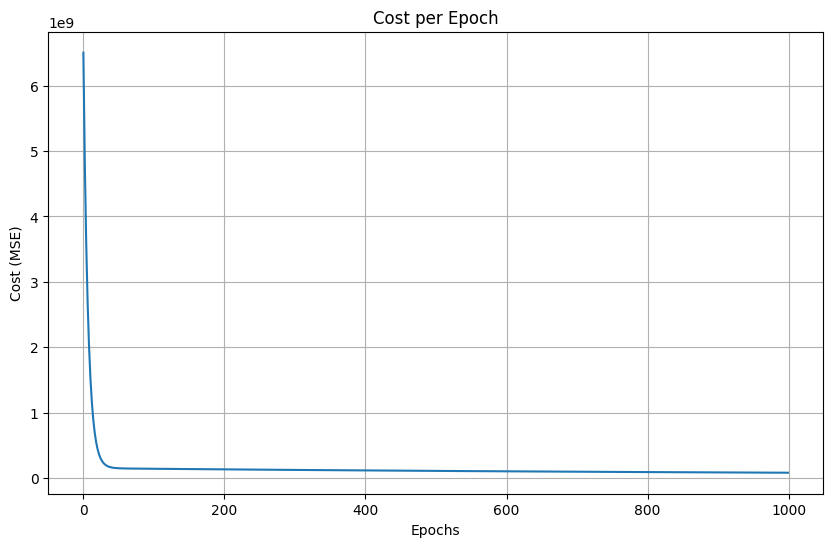

In [19]:
# Step 9: Plot cost function over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), values)
plt.title("Cost per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.grid(True)
plt.show()


**Explanation:**
- This plot visualizes how the cost (MSE) decreases over training iterations
- **X-axis (Epochs)**: Number of iterations (0 to 1000)
- **Y-axis (Cost)**: Mean Squared Error at each epoch
- **What to observe**: 
  - Cost should decrease over time (downward trend)
  - Steep initial drop indicates rapid learning
  - Flattening curve shows convergence (model found optimal parameters)
  - If cost increases, learning rate might be too high
- This is a crucial diagnostic tool to verify gradient descent is working correctly


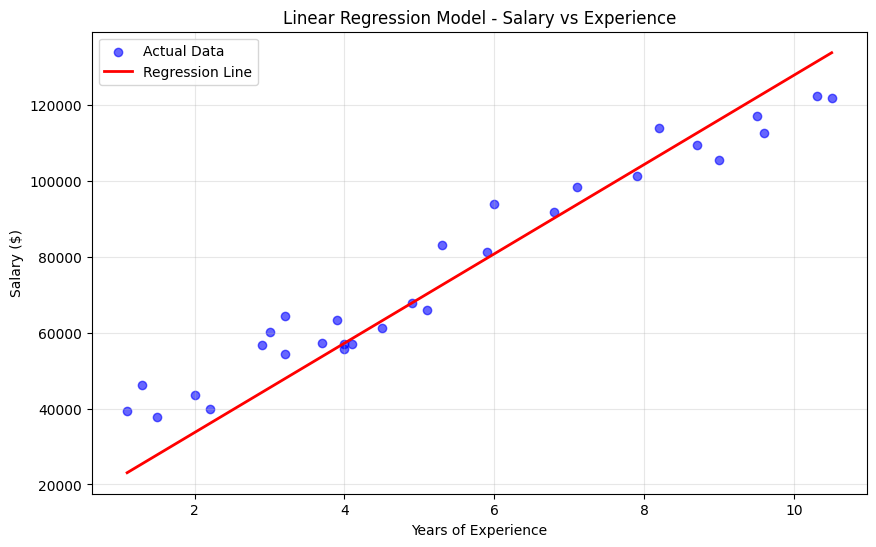

In [20]:
# Step 10: Visualize the regression line with actual data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Actual Data', alpha=0.6)
plt.plot(x, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.title('Linear Regression Model - Salary vs Experience')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Explanation:**
- **Scatter plot (blue dots)**: Shows actual data points (real salary vs experience pairs)
- **Red line**: Our trained regression line showing predicted salaries
- **Purpose**: Visual inspection of how well the model fits the data
- **Good fit**: Points should be close to the line with minimal scatter
- **alpha=0.6**: Makes points semi-transparent to see overlapping data
- **grid**: Helps read values more accurately from the plot
- This visualization helps assess model quality before calculating metrics


In [21]:
# Step 11: Calculate error metrics
MSE_salary = (1/n) * np.sum((y - Y_pred)**2)
print(f"MSE = {MSE_salary}")

RMSE_salary = math.sqrt(MSE_salary)
print(f"RMSE = {RMSE_salary}")


MSE = 84134137.1161153
RMSE = 9172.466250475676


**Explanation - Error Metrics:**

1. **MSE (Mean Squared Error)**:
   - Formula: (1/n) * sum((actual - predicted)²)
   - Averages the squared differences between actual and predicted values
   - **Why square?**: 
     - Penalizes larger errors more heavily
     - Always positive (no cancellation of positive/negative errors)
     - Differentiable (smooth function for optimization)
   - **Lower is better**: Closer to 0 means better predictions

2. **RMSE (Root Mean Squared Error)**:
   - Formula: √MSE
   - Takes square root to bring units back to original scale (dollars in this case)
   - **Interpretation**: Average prediction error in the same units as the target
   - If RMSE = $11,345, it means on average, predictions are off by about $11,345
   - More interpretable than MSE for understanding model performance
